In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración inicial

In [ ]:
from etl_utils import *

In [ ]:
from astrapy import DataAPIClient
# Initialize the client
client = DataAPIClient(token_astra)
db = client.get_database_by_api_endpoint(
  "https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com",
    keyspace="data_users",
)
print(f"Connected to Astra DB: {db.list_collection_names()}")

Connected to Astra DB: ['cleansed_onboarding', 'cleansed_transactions', 'cleansed_users', 'raw_onboarding', 'raw_transactions', 'raw_users']


# **Carga de tablas en Notebook**

In [ ]:
users = pd.read_csv("/content/drive/MyDrive/Código en Python/Minería de datos II/Parcial_2/dim_users.csv")
users.head()

,Unnamed: 0,user_id,name,email,address,birth_dt,phone,type,rubro
0,0,MLB410638994850,Carlos Eduardo Moura,cardosoisabel@example.com,"Feira Sales, 51\nCarmo\n49826-972 da Mata do C...",1958-03-07,84 8887 0394,8.0,1.0
1,1,MLB44585068070,João Vitor Cunha,ana-luizarodrigues@example.com,"Distrito da Luz, 4\nFrei Leopoldo\n71718588 Co...",1978-06-09,51 9358 7614,8.0,9.0
2,2,MLB4815806440,Fernando Costa,nogueirathiago@example.org,"Passarela da Rosa, 95\nGlória\n46105-403 Melo ...",2001-03-13,0300 560 1075,9.0,2.0
3,3,MLB3944955860,Maria Clara Azevedo,souzafrancisco@example.org,"Setor Yago Almeida, 7\nParaíso\n88387-297 Silv...",1915-03-05,+55 (011) 5809 4712,NaN,NaN
4,4,MLB747760490,Srta. Fernanda Jesus,nicolas88@example.org,"Lago de da Rosa, 85\nBelvedere\n41665068 da Ro...",1994-09-27,+55 51 6154 7175,NaN,NaN


In [ ]:
users.columns

Index(['Unnamed: 0', 'user_id', 'name', 'email', 'address', 'birth_dt',
       'phone', 'type', 'rubro'],
      dtype='object')

In [ ]:
# Verifica presencia de NaN, inf o -inf por columna
problemas = users.isin([np.nan, np.inf, -np.inf])
columnas_con_problemas = problemas.any()
columnas_afectadas = columnas_con_problemas[columnas_con_problemas].index.tolist()

print("Columnas con NaN, inf o -inf:")
print(columnas_afectadas)

Columnas con NaN, inf o -inf:
['type', 'rubro']


In [ ]:
transactions = pd.read_csv("/content/drive/MyDrive/Código en Python/Minería de datos II/Parcial_2/fact_users_transactions.csv")
transactions.head()

,Unnamed: 0,user_id,transaction_dt,type,segment
0,0,MLB410542856680,2022-01-20 23:05:07.884739087,9,2
1,1,MLB10610169410,2022-02-06 07:55:58.674812703,1,1
2,2,MLB7813965430,2022-01-25 17:08:53.753615635,6,1
3,3,MLB410646227340,2022-01-28 00:00:00.000000000,8,2
4,4,MLB10664964390,2022-02-02 19:04:18.359600977,7,1


In [ ]:
# Verifica presencia de NaN, inf o -inf por columna
problemas = transactions.isin([np.nan, np.inf, -np.inf])
columnas_con_problemas = problemas.any()
columnas_afectadas = columnas_con_problemas[columnas_con_problemas].index.tolist()

print("Columnas con NaN, inf o -inf:")
print(columnas_afectadas)

Columnas con NaN, inf o -inf:
['transaction_dt']


In [ ]:
onboarding = pd.read_csv("/content/drive/MyDrive/Código en Python/Minería de datos II/Parcial_2/fact_users_onboarding.csv")
onboarding.head()

,Unnamed: 0.1,Unnamed: 0,first_login_dt,week_year,user_id,habito,habito_dt,activacion,activacion_dt,setup,setup_dt,return,return_dt
0,0,9847.0,2022-01-03,1,MLB7745503990,0.0,NaN,0,NaN,0,NaN,0,NaN
1,1,3346.0,2022-01-04,1,MLB10508061470,0.0,NaN,1,2022-01-06,1,2022-01-04,1,2022-01-06
2,2,11261.0,2022-01-23 00:00:00,3,MLB10618286450,0.0,NaN,0,NaN,0,NaN,0,NaN
3,3,6273.0,2022-01-03,1,MLB743362200,0.0,NaN,1,2022-01-03,0,NaN,0,NaN
4,4,860.0,2022-01-16,2,MLB2467761450,0.0,NaN,1,2022-01-17,1,2022-01-17,1,2022-01-17


In [ ]:
# Verifica presencia de NaN, inf o -inf por columna
problemas = onboarding.isin([np.nan, np.inf, -np.inf])
columnas_con_problemas = problemas.any()
columnas_afectadas = columnas_con_problemas[columnas_con_problemas].index.tolist()

print("Columnas con NaN, inf o -inf:")
print(columnas_afectadas)

Columnas con NaN, inf o -inf:
['Unnamed: 0', 'habito', 'habito_dt', 'activacion_dt', 'setup_dt', 'return_dt']


# **Primera parte: Landing**

**Función insertar_si_vacía**
La función insertar_si_vacia(df, coleccion) recibe dos parámetros: un DataFrame (df) y el nombre de una colección en la base de datos (coleccion). Primero, limpia el DataFrame reemplazando valores NaN por None y lo convierte en una lista de diccionarios compatibles con JSON. Luego, en la base de datos de DataStax Astra, verifica si la colección existe y si está vacía. Si no existe, la crea; y si está vacía, inserta los datos. Si ya contiene documentos, no realiza ninguna inserción.

In [ ]:
def insertar_si_vacia(df, coleccion):
    # Reemplaza valores NaN por None para que sean compatibles con JSON
    df_clean = df.where(pd.notnull(df), None)

    # Convierte cualquier objeto tipo fecha (datetime.date o datetime.datetime) a string con formato 'YYYY-MM-DD'
    df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)

    # Convierte el DataFrame en una lista de diccionarios (registros) listos para ser insertados
    # Asegura que todos los valores sean del tipo adecuado para JSON (nativos de Python)
    records = df_clean.astype(object).where(pd.notnull(df_clean), None).to_dict(orient='records')
    records = json.loads(json.dumps(records))  # Serializa y deserializa para garantizar compatibilidad total con JSON

    # Si la colección no existe en la base, la crea; si ya existe, la obtiene
    if coleccion not in db.list_collection_names():
        collection = db.create_collection(coleccion)
    else:
        collection = db.get_collection(coleccion)

    # Inserta los registros solo si la colección está vacía
    if collection.find_one() is None:
        collection.insert_many(records)
        print(f"Se han insertado los registros en la colección {coleccion}.")
    else:
        print(f"La colección {coleccion} ya contiene los datos requeridos.")

In [ ]:
insertar_si_vacia(users, "raw_users")

/tmp/ipython-input-119-2864727709.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)


La colección raw_users ya contiene los datos requeridos.


In [ ]:
insertar_si_vacia(onboarding, "raw_onboarding")

/tmp/ipython-input-119-2864727709.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)


La colección raw_onboarding ya contiene los datos requeridos.


In [ ]:
insertar_si_vacia(transactions, "raw_transactions")

/tmp/ipython-input-119-2864727709.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)


La colección raw_transactions ya contiene los datos requeridos.


# **Segunda parte: Universal**

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder \
        .appName('Universal Zone') \
        .config("spark.sql.catalogImplementation", "hive") \
        .enableHiveSupport() \
        .getOrCreate()

## 1. Ingesta

In [ ]:
# Conexión a la base de datos para traer la colección 'raw_users'
raw_users = db.get_collection("raw_users")
raw_users

Collection(name="raw_users", keyspace="data_users", database.api_endpoint="https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:XfPo...), ...))

In [ ]:
# Conexión a la base de datos para traer la colección 'raw_onboarding'
raw_onboarding = db.get_collection("raw_onboarding")
raw_onboarding

Collection(name="raw_onboarding", keyspace="data_users", database.api_endpoint="https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:XfPo...), ...))

In [ ]:
# Conexión a la base de datos para traer la colección 'raw_transactions'
raw_transactions = db.get_collection("raw_transactions")
raw_transactions

Collection(name="raw_transactions", keyspace="data_users", database.api_endpoint="https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:XfPo...), ...))

In [ ]:
# Se importan todos los tipos de datos
from pyspark.sql.types import *

### Tabla 'users_df'

In [ ]:
# 1. Se define el esquema en PySpark para el DataFrame 'users', indicando el nombre, tipo y si acepta valores nulos por cada campo.
     #birth_dt queda como StringType para crear el DataFrame inicialmente

schema_users = StructType([
    StructField("user_id", StringType(), True),
    StructField("name", StringType(), True),
    StructField("email", StringType(), True),
    StructField("address", StringType(), True),
    StructField("birth_dt", StringType(), True),
    StructField("phone", StringType(), True),
    StructField("type", StringType(), True),
    StructField("rubro", StringType(), True)
])

# En PySpark, cuando definís un esquema con StructField, el tercer parámetro indica si esa columna puede contener valores nulos.
# True significa que la columna puede tener valores nulos (por ejemplo, null o None en los datos).
# Si ponemos False, estarías diciendo que esa columna no puede tener ningún valor nulo — y si encuentra uno al leer los datos, lanzará un error.
# Al definir True, te asegurás de que Spark acepte esos valores y no falle al cargar el DataFrame.

In [ ]:
# 2. Se extraen los datos desde Cassandra y se construyen los registros como tuplas
# Porque al usar datos provenientes de Cassandra (o MongoDB), doc es un diccionario. Para crear el DataFrame en Spark con un esquema definido (schema_users),
# se  necesita una lista de filas, y cada fila se representa como una tupla ordenada.
reg_users = [
    (
        str(doc.get("user_id", "")),
        str(doc.get("name", "")),
        str(doc.get("email", "")),
        str(doc.get("address", "")),
        str(doc.get("birth_dt", "")),
        str(doc.get("phone", "")),
        str(doc.get("type", "")),
        str(doc.get("rubro", ""))
    )
    for doc in raw_users.find()
]

In [ ]:
reg_users

[('MLB10592694110',
  'Sarah da Mata',
  'barbosaanthony@example.com',
  'Alameda da Cruz, 238\nNovo Aarão Reis\n22578-049 Costa da Prata / AP',
  '1966-11-10',
  '+55 (061) 7657 4770',
  'None',
  'None'),
 ('MLB2141666680',
  'Luiz Gustavo Silveira',
  'xcavalcanti@example.net',
  'Condomínio de Cavalcanti, 5\nVila Nova Gameleira 2ª Seção\n13439-736 da Paz / MA',
  '1933-06-08',
  '+55 21 0855-5906',
  'None',
  'None'),
 ('MLB2966842010',
  'Luiz Otávio Teixeira',
  'clariceda-mata@example.net',
  'Residencial Arthur da Conceição, 8\nConjunto Califórnia I\n73378-701 Nunes / SC',
  '1973-02-28',
  '0300 315 4660',
  'None',
  'None'),
 ('MLB6887848060',
  'Emanuel Campos',
  'ldas-neves@example.org',
  'Aeroporto Raul Aragão, 5\nSerra Verde\n86653828 Sales / MA',
  '1911-01-15',
  '(051) 1169-4590',
  'None',
  'None'),
 ('MLB7758191400',
  'Mirella Santos',
  'sofiagoncalves@example.net',
  'Esplanada de Peixoto\nVila Real 2ª Seção\n89563691 Pereira / PE',
  '1977-10-16',
  '+55 71 

In [ ]:
# 3. Se Creaa el DataFrame en Spark
users_df = spark.createDataFrame(reg_users, schema_users)
users_df

DataFrame[user_id: string, name: string, email: string, address: string, birth_dt: string, phone: string, type: string, rubro: string]

In [ ]:
# 4. Se imprime el esquema del DataFrame de users_df
users_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- address: string (nullable = true)
 |-- birth_dt: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rubro: string (nullable = true)



In [ ]:
# 5. Se muestran cómo quedó el esquema de la tabla users_df
users_df.show()

+----------------+--------------------+--------------------+--------------------+----------+-------------------+----+-----+
|         user_id|                name|               email|             address|  birth_dt|              phone|type|rubro|
+----------------+--------------------+--------------------+--------------------+----------+-------------------+----+-----+
|  MLB10592694110|       Sarah da Mata|barbosaanthony@ex...|Alameda da Cruz, ...|1966-11-10|+55 (061) 7657 4770|None| None|
|   MLB2141666680|Luiz Gustavo Silv...|xcavalcanti@examp...|Condomínio de Cav...|1933-06-08|   +55 21 0855-5906|None| None|
|   MLB2966842010|Luiz Otávio Teixeira|clariceda-mata@ex...|Residencial Arthu...|1973-02-28|      0300 315 4660|None| None|
|   MLB6887848060|      Emanuel Campos|ldas-neves@exampl...|Aeroporto Raul Ar...|1911-01-15|    (051) 1169-4590|None| None|
|   MLB7758191400|      Mirella Santos|sofiagoncalves@ex...|Esplanada de Peix...|1977-10-16|   +55 71 1653 6794|None| None|
|   MLB2

### Tabla 'transactions_df'

In [ ]:
# 1. Se define el esquema en PySpark para el DataFrame 'transactions', indicando el nombre, tipo y si acepta valores nulos por cada campo.
schema_transactions = StructType([
    StructField("Unnamed: 0", IntegerType(), True),
    StructField("user_id", StringType(), True),
    StructField("transaction_dt", StringType(), True),
    StructField("type", StringType(), True),
    StructField("segment", IntegerType(), True)
])

In [ ]:
# # 2. Se extraen los datos desde Cassandra y se construyen los registros como tuplas
# Al usar datos provenientes de Cassandra (o MongoDB), doc es un diccionario. Para crear el DataFrame en Spark con un esquema definido (schema_transactions),
# se necesita una lista de filas, y cada fila se representa como una tupla ordenada.
reg_transactions = [
    (
        int(doc.get("Unnamed: 0") or 0),
        str(doc.get("user_id") or ""),
        str(doc.get("transaction_dt") or ""),
        str(doc.get("type") or ""),
        int(doc.get("segment") or 0),
        )
    for doc in raw_transactions.find()
]

In [ ]:
# 3. Se crea el DataFrame en Spark
transactions_df = spark.createDataFrame(reg_transactions, schema_transactions)
transactions_df

DataFrame[Unnamed: 0: int, user_id: string, transaction_dt: string, type: string, segment: int]

In [ ]:
# 4. Se imprime el esquema del DataFrame de transacciones
transactions_df.printSchema()

root
 |-- Unnamed: 0: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- transaction_dt: string (nullable = true)
 |-- type: string (nullable = true)
 |-- segment: integer (nullable = true)



In [ ]:
# 5. Se muestran cómo quedó el esquema de la tabla transactions
transactions_df.show()

+----------+----------------+--------------------+----+-------+
|Unnamed: 0|         user_id|      transaction_dt|type|segment|
+----------+----------------+--------------------+----+-------+
|      3321|   MLB7354875930|2022-01-31 03:00:...|   3|      1|
|      7154|   MLB5157262920|2022-02-07 06:39:...|   4|      1|
|      1019|  MLB10642706010|2022-02-20 06:39:...|   2|      1|
|      5700|  MLB10510053700|2022-01-19 21:26:...|   7|      1|
|      3746|  MLB10641359970|2022-01-29 00:00:...|   3|      1|
|      5370|  MLB44818127630|2022-01-09 21:15:...|   9|      2|
|      1191|MLB10595880640-1|2022-01-19 00:00:...|   4|      1|
|      2753|  MLB10567422320|2022-02-04 10:56:...|   6|      1|
|      1497|   MLB2159161160|2022-01-27 00:00:...|   2|      1|
|      2379| MLB410405074322|2022-01-07 21:42:...|   8|      2|
|       893|   MLB8372304010|2022-01-14 00:00:...|   3|      1|
|      6422|  MLB10598640960|2022-01-23 23:21:...|   7|      1|
|      3491|   MLB4773716710|2022-01-30 

### Tabla 'onboarding_df'

In [ ]:
# 1. Se define el esquema en PySpark para el DataFrame 'onboarding', indicando el nombre, tipo y si acepta valores nulos por cada campo.
     #Las columnas de fecha se cargan inicialmente como StringType y luego se convertirán a tipo fecha.
schema_onboarding = StructType([
    StructField("Unnamed: 0", IntegerType(), True),         # índice del CSV
    StructField("first_login_dt", StringType(), True),      # fecha de primer login
    StructField("week_year", StringType(), True),           # semana del año
    StructField("user_id", StringType(), True),             # ID de usuario
    StructField("habito", DoubleType(), True),              # valor numérico (0.0 o 0.1)
    StructField("habito_dt", StringType(), True),           # fecha
    StructField("activacion", BooleanType(), True),         # booleano
    StructField("activacion_dt", StringType(), True),       # fecha
    StructField("setup", BooleanType(), True),              # booleano
    StructField("setup_dt", StringType(), True),            # fecha
    StructField("return", BooleanType(), True),             # booleano
    StructField("return_dt", StringType(), True)            # fecha
])

In [ ]:
# 2. Se extraen los datos desde Cassandra y se construyen los registros como tuplas
# Porque al usar datos provenientes de Cassandra (o MongoDB), doc es un diccionario. Para crear el DataFrame en Spark con un esquema definido (schema_onboarding),
# necesitas una lista de filas, y cada fila se representa como una tupla ordenada.
reg_onboarding = [
    (
        int(doc.get("Unnamed: 0") or 0),
        str(doc.get("first_login_dt") or ""),
        str(doc.get("week_year") or ""),
        str(doc.get("user_id") or ""),
        float(doc.get("habito") or 0.0),
        str(doc.get("habito_dt") or ""),
        bool(doc.get("activacion") or False),
        str(doc.get("activacion_dt") or ""),
        bool(doc.get("setup") or False),
        str(doc.get("setup_dt") or ""),
        bool(doc.get("return") or False),
        str(doc.get("return_dt") or "")
    )
    for doc in raw_onboarding.find()
]

In [ ]:
reg_onboarding

[(11366,
  '2022-01-21 00:00:00',
  '3',
  'MLB10608114960',
  0.0,
  '',
  True,
  '2022-01-21 00:00:00',
  True,
  '2022-01-21 00:00:00',
  True,
  '2022-01-24 00:00:00'),
 (0,
  '2022-01-14',
  '2',
  'MLB443234120',
  0.0,
  '',
  False,
  '',
  False,
  '',
  False,
  ''),
 (2302,
  '2022-01-06',
  '1',
  'MLB10524181020',
  0.0,
  '',
  True,
  '2022-01-21',
  False,
  '',
  True,
  '2022-01-21'),
 (0,
  '2022-01-30',
  '4',
  'MLB47802443410',
  0.0,
  '',
  True,
  '2022-01-30',
  True,
  '2022-01-30',
  True,
  '2022-01-31'),
 (0,
  '2022-01-03',
  '1',
  'MLB43981217222',
  0.0,
  '',
  False,
  '',
  False,
  '',
  True,
  '2022-01-09'),
 (9015,
  '2022-01-03',
  '1',
  'MLB4893417900',
  0.0,
  '',
  False,
  '',
  False,
  '',
  True,
  '2022-01-04'),
 (7998,
  '2022-01-10',
  '2',
  'MLB10537220730',
  1.0,
  '2022-01-11',
  True,
  '2022-01-10',
  True,
  '2022-01-11',
  True,
  '2022-01-11'),
 (7783,
  '2022-01-28',
  '4',
  'MLB1931387280',
  0.0,
  '',
  True,
  '2022

In [ ]:
# 3. Se crea el DataFrame en Spark
onboarding_df = spark.createDataFrame(reg_onboarding, schema_onboarding)

In [ ]:
# 4. Se imprime el esquema del DataFrame de onboarding
onboarding_df.printSchema()

root
 |-- Unnamed: 0: integer (nullable = true)
 |-- first_login_dt: string (nullable = true)
 |-- week_year: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: double (nullable = true)
 |-- habito_dt: string (nullable = true)
 |-- activacion: boolean (nullable = true)
 |-- activacion_dt: string (nullable = true)
 |-- setup: boolean (nullable = true)
 |-- setup_dt: string (nullable = true)
 |-- return: boolean (nullable = true)
 |-- return_dt: string (nullable = true)



In [ ]:
# 5. Se muestran cómo quedó el esquema de la tabla onboardings
onboarding_df.show()

+----------+-------------------+---------+---------------+------+----------+----------+-------------------+-----+-------------------+------+-------------------+
|Unnamed: 0|     first_login_dt|week_year|        user_id|habito| habito_dt|activacion|      activacion_dt|setup|           setup_dt|return|          return_dt|
+----------+-------------------+---------+---------------+------+----------+----------+-------------------+-----+-------------------+------+-------------------+
|     11366|2022-01-21 00:00:00|        3| MLB10608114960|   0.0|          |      true|2022-01-21 00:00:00| true|2022-01-21 00:00:00|  true|2022-01-24 00:00:00|
|         0|         2022-01-14|        2|   MLB443234120|   0.0|          |     false|                   |false|                   | false|                   |
|      2302|         2022-01-06|        1| MLB10524181020|   0.0|          |      true|         2022-01-21|false|                   |  true|         2022-01-21|
|         0|         2022-01-30|  

## 2. Limpieza

In [ ]:
# Se importan todas las funciones disponibles del módulo pyspark.sql.functions,
# como col, lit, when, sum, entre otras, para usarlas en transformaciones de DataFrames en PySpark.
from pyspark.sql.functions import *

### Limpieza user_df

In [ ]:
cleansed_users_df = users_df

**Se eliminan columnas innecesarias para el análisis y el objetivo de negocio:**

- name: no	No aporta valor al análisis, y puede comprometer la privacidad.

- email: No	Idem anterior: sin valor analítico, y sensible.

- address: No	No se requiere para calcular ninguna métrica, y es dato sensible.

- phone: no tiene utilidad para análisis de onboarding ni métricas.

- type: No se utiliza para calcular ninguna de las métricas de onboarding (drop, activación, hábito o setup), ni es un atributo mencionado en los objetivos analíticos del proyecto.


In [ ]:
cleansed_users_df = cleansed_users_df.drop("name", "email", "address", "phone", "type")

**Se cambia el tipo de la columna rubro a IntegerType**

Se transforma a tipo entero (IntegerType) para permitir su uso en consultas analíticas, segmentaciones y agrupamientos. Al tratarse de un identificador de categoría de negocio para usuarios del segmento seller, su interpretación como número entero facilita comparaciones, filtrado y análisis eficientes en Spark.

In [ ]:
# El siguiente código transforma la columna rubro de cleansed_users_df a tipo entero, conservando el resto del DataFrame sin modificaciones:
cleansed_users_df = cleansed_users_df.withColumn("rubro", col("rubro").cast(IntegerType()))

In [ ]:
# Verificación de cambio efectuado
cleansed_users_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- birth_dt: string (nullable = true)
 |-- rubro: integer (nullable = true)



**Se verifica que todos los usuarios sean de Brasil**

La experimentación de seis meses se focaliza en usuarios de Brasil, por lo que se chequea que todos los registros de la columna 'user_id' comiencen con 'MLB'.

Se verifica que todos los usuarios comienzan con dicha sigla: no se elimina ningún registro.

In [ ]:
# Mostrar la cantidad total de usuarios en el dataset original
print(f"Cantidad de usuarios del dataset: {cleansed_users_df.count()}")

# Filtrar registros cuyo user_id comienza con 'MLB'
dim_users_filtrado = cleansed_users_df.filter(col("user_id").startswith("MLB"))

# Mostrar la cantidad de usuarios válidos (de Brasil)
print(f"Cantidad de usuarios válidos (user_id comienza con 'MLB'): {dim_users_filtrado.count()}")

Cantidad de usuarios del dataset: 13000
Cantidad de usuarios válidos (user_id comienza con 'MLB'): 13000


**Transformación de la coluna fecha de DateType**

Se transforma birth_dt: al tipo date para asegurar su correcta interpretación como fecha y permitir operaciones temporales precisas, como el cálculo de edad, segmentación por rangos etarios o comparación con otras fechas (por ejemplo, fecha de login).


In [ ]:
cleansed_users_df = cleansed_users_df.withColumn("birth_dt", to_date("birth_dt", "yyyy-MM-dd"))

# Verificación de cambio efectuado
cleansed_users_df.printSchema()
cleansed_users_df.select("birth_dt").show(5)

root
 |-- user_id: string (nullable = true)
 |-- birth_dt: date (nullable = true)
 |-- rubro: integer (nullable = true)

+----------+
|  birth_dt|
+----------+
|1966-11-10|
|1933-06-08|
|1973-02-28|
|1911-01-15|
|1977-10-16|
+----------+
only showing top 5 rows



**Verificación de valores nulos**: no los hay

In [ ]:
cleansed_users_df.select([
    sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c)
    for c in cleansed_users_df.columns
]).show()

+-------+--------+-----+
|user_id|birth_dt|rubro|
+-------+--------+-----+
|      0|       0|11000|
+-------+--------+-----+



**Verificación de valores duplicados**: no los hay

In [ ]:
# Se verifica la presencia duplicados por user_id
cleansed_users_df.groupBy("user_id").agg(count("*").alias("cantidad")).filter("cantidad > 1").show()

+-------+--------+
|user_id|cantidad|
+-------+--------+
+-------+--------+



### Limpieza  'transactions_df'

In [ ]:
cleansed_transactions_df = transactions_df

**Se elimina la columna Unnamed**

Es una columna que se genera automáticamente cuando un archivo CSV tiene un índice sin nombre al momento de ser exportado. No tiene valor analítico y no representa una variable real del negocio:

-No cumple ningún propósito.

-No aporta información útil para el análisis posterior.

-Fue usada solo como índice al leer el CSV original.

In [ ]:
cleansed_transactions_df = cleansed_transactions_df.drop("Unnamed: 0")

**Se cambia transaction_dt a tipo Date**

Se transforma la columna transaction_dt a tipo date para asegurar que las fechas de transacción tengan un formato válido y uniforme, eliminando al mismo tiempo la hora. Esto permite realizar comparaciones cronológicas, agrupamientos por fecha y filtros temporales precisos. Esta conversión también permite detectar y descartar registros con fechas mal formateadas o inconsistentes antes de persistir los datos en Cassandra.
Se Conserva sólo la fecha para simplificar el dataset y mejorar su claridad, como parte de la limpieza

In [ ]:
# Se verifica el tipo de dato que tiene la columna apuntada
print("transaction_dt:", cleansed_transactions_df.schema["transaction_dt"].dataType)

transaction_dt: StringType()


In [ ]:
# Se realiza el cambio a tipo date
cleansed_transactions_df = cleansed_transactions_df.withColumn(
    "transaction_dt", to_date(to_timestamp("transaction_dt", "yyyy-MM-dd HH:mm:ss.SSSSSSSSS"))
)

In [ ]:
# Se verifica el cambio observando el esquema
cleansed_transactions_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- transaction_dt: date (nullable = true)
 |-- type: string (nullable = true)
 |-- segment: integer (nullable = true)



In [ ]:
# Se verifica visualmente que la columna transaction_dt fue correctamente transformada a tipo fecha
cleansed_transactions_df.select("transaction_dt").show(5, truncate=False)

+--------------+
|transaction_dt|
+--------------+
|2022-01-31    |
|2022-02-07    |
|2022-02-20    |
|2022-01-19    |
|2022-01-29    |
+--------------+
only showing top 5 rows



**Se verifica si hay valores nulos, por columna**

Se verifican 20 valores nulos en la columna transaction_dt: fecha de una transacción realizada por el usuario

In [ ]:
for c in cleansed_transactions_df.columns:
    try:
        nulos = cleansed_transactions_df.filter(col(c).isNull()).count()
        print(f"{c}: {nulos} valores nulos")
    except Exception as e:
        print(f"Error en columna '{c}': {e}")

user_id: 0 valores nulos
transaction_dt: 20 valores nulos
type: 0 valores nulos
segment: 0 valores nulos


In [ ]:
# Se eliminan los 20 registro nulos
cleansed_transactions_df = cleansed_transactions_df.filter(col("transaction_dt").isNotNull())

# Se chequea nuevamente que ya no existan:
print("Valores nulos en columna transactions_df:", cleansed_transactions_df.filter(col("transaction_dt").isNull()).count())

Valores nulos en columna transactions_df: 0


**Detección de duplicados**
Se utiliza groupBy("user_id", "transaction_dt", "type") para identificar transacciones duplicadas realizadas por el mismo usuario, en la misma fecha y con el mismo tipo.
Estas tres columnas combinadas definen una transacción única según la lógica del negocio, por lo que las repeticiones indican duplicación.

In [ ]:
cleansed_transactions_df.groupBy("user_id", "transaction_dt", "type").count().filter("count > 1").show()

+---------------+--------------+----+-----+
|        user_id|transaction_dt|type|count|
+---------------+--------------+----+-----+
| MLB10614326890|    2022-02-09|   1|    2|
|  MLB5096228410|    2022-01-28|   1|    2|
|   MLB693861640|    2022-02-02|   2|    2|
|MLB8330873600-1|    2022-02-14|   4|    2|
| MLB10565586390|    2022-01-17|   1|    2|
|  MLB7679060870|    2022-01-30|   6|    2|
|  MLB2935061670|    2022-01-21|   6|    2|
| MLB10571240970|    2022-02-01|   2|    3|
|  MLB5720286050|    2022-02-06|   1|    2|
|  MLB2371695360|    2022-01-25|   2|    3|
| MLB42642162970|    2022-01-29|   9|    2|
| MLB10635942760|    2022-01-26|   4|    2|
|  MLB1930664270|    2022-01-28|   4|    3|
|  MLB7900206920|    2022-01-16|   3|    2|
| MLB10390720050|    2022-01-16|   2|    2|
| MLB10589263600|    2022-01-27|   5|    2|
| MLB48407598470|    2022-02-07|   9|    3|
|  MLB1929492970|    2022-01-29|   3|    3|
| MLB47453621570|    2022-02-18|   9|    5|
| MLB10654114570|    2022-02-18|

In [ ]:
# Se eliminan duplicados
cleansed_transactions_df = cleansed_transactions_df.dropDuplicates(["user_id", "transaction_dt", "type"])

In [ ]:
# Verificación final de duplicados:
cleansed_transactions_df.groupBy("user_id", "transaction_dt", "type") \
    .count() \
    .filter("count > 1") \
    .show()

+-------+--------------+----+-----+
|user_id|transaction_dt|type|count|
+-------+--------------+----+-----+
+-------+--------------+----+-----+



### Limpieza 'onboarding_df'

In [ ]:
cleansed_onboarding_df = onboarding_df

**Se elimina la columna Unnamed**

Es una columna que se genera automáticamente cuando un archivo CSV tiene un índice sin nombre al momento de ser exportado. No tiene valor analítico y no representa una variable real del negocio:

-No cumple ningún propósito.

-No aporta información útil para el análisis posterior.

-Fue usada solo como índice al leer el CSV original.

In [ ]:
cleansed_onboarding_df = cleansed_onboarding_df.drop("Unnamed: 0")

In [ ]:
# Se verifica que haya sido eliminada
cleansed_onboarding_df.printSchema()

root
 |-- first_login_dt: string (nullable = true)
 |-- week_year: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: double (nullable = true)
 |-- habito_dt: string (nullable = true)
 |-- activacion: boolean (nullable = true)
 |-- activacion_dt: string (nullable = true)
 |-- setup: boolean (nullable = true)
 |-- setup_dt: string (nullable = true)
 |-- return: boolean (nullable = true)
 |-- return_dt: string (nullable = true)



**Conversión a tipo date de las columnas que registran fechas**

Las columnas *_dt de cleansed_onboarding_df (como first_login_dt, habito_dt, activacion_dt, setup_dt y return_dt) se convierten a tipo date para:

- Validar el formato y contenido de las fechas originales, muchas de las cuales incluyen hora (timestamp).

- Estandarizar el valor final como fecha (yyyy-MM-dd), descartando la hora si no se necesita para las métricas de onboarding.

- Facilitar operaciones cronológicas como filtrado, comparación y agrupamiento por fecha en etapas posteriores.

- Prevenir errores al subir los datos a Cassandra, donde las fechas deben estar bien formateadas y consistentes.

In [ ]:
# Se verifica el tipo de dato que contienen las columnas apuntadas:
print("first_login_dt:", cleansed_onboarding_df.schema["first_login_dt"].dataType)
print("habito_dt:", cleansed_onboarding_df.schema["habito_dt"].dataType)
print("activacion_dt:", cleansed_onboarding_df.schema["activacion_dt"].dataType)
print("setup_dt:", cleansed_onboarding_df.schema["setup_dt"].dataType)
print("return_dt:", cleansed_onboarding_df.schema["return_dt"].dataType)

first_login_dt: StringType()
habito_dt: StringType()
activacion_dt: StringType()
setup_dt: StringType()
return_dt: StringType()


In [ ]:
# Se realiza el cambio a tipo date:
cleansed_onboarding_df = cleansed_onboarding_df \
    .withColumn("first_login_dt", to_date(to_timestamp("first_login_dt", "yyyy-MM-dd HH:mm:ss"))) \
    .withColumn("habito_dt", to_date(to_timestamp("habito_dt", "yyyy-MM-dd HH:mm:ss"))) \
    .withColumn("activacion_dt", to_date(to_timestamp("activacion_dt", "yyyy-MM-dd HH:mm:ss"))) \
    .withColumn("setup_dt", to_date(to_timestamp("setup_dt", "yyyy-MM-dd HH:mm:ss"))) \
    .withColumn("return_dt", to_date(to_timestamp("return_dt", "yyyy-MM-dd HH:mm:ss")))

In [ ]:
# Se verifican los cambios observando el esquema:
cleansed_onboarding_df.printSchema()

root
 |-- first_login_dt: date (nullable = true)
 |-- week_year: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: double (nullable = true)
 |-- habito_dt: date (nullable = true)
 |-- activacion: boolean (nullable = true)
 |-- activacion_dt: date (nullable = true)
 |-- setup: boolean (nullable = true)
 |-- setup_dt: date (nullable = true)
 |-- return: boolean (nullable = true)
 |-- return_dt: date (nullable = true)



In [ ]:
# Se verifica visualmente la correcta transformación a tipo date de las columnas apuntadas.
# Las columnas de fecha contienen valores NULL cuando el evento asociado (como activación, retorno o hábito) no ocurrió.
# Esta ausencia es esperable y refleja el comportamiento real de los usuarios.
cleansed_onboarding_df.select(
    "first_login_dt",
    "habito_dt",
    "activacion_dt",
    "setup_dt",
    "return_dt"
).show(20, truncate=False)

+--------------+---------+-------------+----------+----------+
|first_login_dt|habito_dt|activacion_dt|setup_dt  |return_dt |
+--------------+---------+-------------+----------+----------+
|2022-01-21    |NULL     |2022-01-21   |2022-01-21|2022-01-24|
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL      |
|NULL          |NULL     |NULL         |NULL      |NULL

**Eliminación de duplicados en columna "user_id"**

In [ ]:
# Se identifica si hay usuarios (user_id) duplicados y se muestra cuántas veces aparecen.
cleansed_onboarding_df.groupBy("user_id") \
    .agg(count("*").alias("cantidad")) \
    .filter("cantidad > 1") \
    .show()

+--------------+--------+
|       user_id|cantidad|
+--------------+--------+
| MLB2611445900|       2|
|MLB10585324220|       2|
|MLB10641923710|       2|
| MLB2384284940|       2|
| MLB1798649690|       2|
|MLB10616167040|       2|
| MLB4257979010|       2|
| MLB5759571320|       2|
|MLB10579932080|       2|
| MLB8033217490|       2|
| MLB8352562620|       2|
|  MLB767890190|       2|
| MLB2917227310|       2|
|MLB10647858090|       2|
|MLB10386505260|       2|
| MLB2310748780|       2|
| MLB2090210990|       2|
| MLB8026432710|       2|
| MLB5141537600|       2|
|MLB10653748730|       2|
+--------------+--------+
only showing top 20 rows



Se utiliza dropDuplicates(["user_id"]) para eliminar registros repetidos que compartían el mismo identificador de usuario.
Los duplicados detectados eran idénticos en contenido, diferenciándose solo por el formato original de las fechas (con o sin hora).
Como previamente se estandarizó el formato de fechas usando to_date(...), fue posible identificar estas filas como redundantes y conservar solo una por usuario.

In [ ]:
cleansed_onboarding_df = cleansed_onboarding_df.dropDuplicates(["user_id"])

In [ ]:
# Verificación de duplicados eliminados:
cleansed_onboarding_df.groupBy("user_id") \
    .agg(count("*").alias("cantidad")) \
    .filter("cantidad > 1") \
    .show()

+-------+--------+
|user_id|cantidad|
+-------+--------+
+-------+--------+



**Se cambia el tipo de las siguientes columnas a IntegerType**

- 'habito': de DoubleType a IntegerType para facilitar filtros, joins y comparaciones.

- 'week_year': de StringType a IntegerType para permitir ordenamientos y agrupaciones cronológicas.

- 'activacion', 'setup' y 'return': de BooleanType a IntegerType para simplificar cálculos binarios y permitir agregaciones numéricas (ej. medias, conteos).

In [ ]:
# Paso 1: se verifica el tipo de dato de la columna habito
print("▶ Tipos originales:")
print("habito:", cleansed_onboarding_df.schema["habito"].dataType)
print("week_year:", cleansed_onboarding_df.schema["week_year"].dataType)
print("activacion:", cleansed_onboarding_df.schema["activacion"].dataType)
print("setup:", cleansed_onboarding_df.schema["setup"].dataType)
print("return:", cleansed_onboarding_df.schema["return"].dataType)

▶ Tipos originales:
habito: DoubleType()
week_year: StringType()
activacion: BooleanType()
setup: BooleanType()
return: BooleanType()


In [ ]:
# Paso 2: Conversión a IntegerType
cleansed_onboarding_df = cleansed_onboarding_df \
    .withColumn("habito", col("habito").cast("int")) \
    .withColumn("week_year", col("week_year").cast("int")) \
    .withColumn("activacion", col("activacion").cast("int")) \
    .withColumn("setup", col("setup").cast("int")) \
    .withColumn("return", col("return").cast("int"))

In [ ]:
# Paso 3: se verifican los cambios
cleansed_onboarding_df.printSchema()

root
 |-- first_login_dt: date (nullable = true)
 |-- week_year: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: integer (nullable = true)
 |-- habito_dt: date (nullable = true)
 |-- activacion: integer (nullable = true)
 |-- activacion_dt: date (nullable = true)
 |-- setup: integer (nullable = true)
 |-- setup_dt: date (nullable = true)
 |-- return: integer (nullable = true)
 |-- return_dt: date (nullable = true)



**Verificamos ahora inconsistencias lógicas según la consigna**

*Reglas de negocio esperadas:*

-Si hábito = 1, entonces debería haber activacion = 1

-Si setup = 1, debería existir setup_dt

-Si return = 1, debería haber return_dt

In [ ]:
# Inconsistencia 1: habito = 1 pero activacion = 0
cleansed_onboarding_df.filter((col("habito") == 1) & (col("activacion") == 0)).show()

+--------------+---------+---------------+------+---------+----------+-------------+-----+--------+------+---------+
|first_login_dt|week_year|        user_id|habito|habito_dt|activacion|activacion_dt|setup|setup_dt|return|return_dt|
+--------------+---------+---------------+------+---------+----------+-------------+-----+--------+------+---------+
|          NULL|        2| MLB10554685650|     1|     NULL|         0|         NULL|    0|    NULL|     1|     NULL|
|          NULL|        5| MLB10660135740|     1|     NULL|         0|         NULL|    0|    NULL|     1|     NULL|
|          NULL|        5| MLB10661666960|     1|     NULL|         0|         NULL|    1|    NULL|     1|     NULL|
|          NULL|        2|MLB410554685650|     1|     NULL|         0|         NULL|    0|    NULL|     1|     NULL|
+--------------+---------+---------------+------+---------+----------+-------------+-----+--------+------+---------+



**Se aliminan esas filas, ya que contradicen la lógica del negocio**

No es consistente que un usuario haya llegado al hábito, pero no tenga activación (no es lógico)

In [ ]:
cleansed_onboarding_df = cleansed_onboarding_df.filter(~((col("habito") == 1) & (col("activacion") == 0)))

In [ ]:
# Se chequea si las inconsistencias fueron eliminadas. Si 1: habito = 1 pero activacion = 0
cleansed_onboarding_df.filter((col("habito") == 1) & (col("activacion") == 0)).show()

+--------------+---------+-------+------+---------+----------+-------------+-----+--------+------+---------+
|first_login_dt|week_year|user_id|habito|habito_dt|activacion|activacion_dt|setup|setup_dt|return|return_dt|
+--------------+---------+-------+------+---------+----------+-------------+-----+--------+------+---------+
+--------------+---------+-------+------+---------+----------+-------------+-----+--------+------+---------+



In [ ]:
# Este código devuelve 0, por lo cual la limpieza fue exitosa.
print("Cantidad de incosistencias de hábito sin activación:", cleansed_onboarding_df.filter((col("habito") == 1) & (col("activacion") == 0)).count())

Cantidad de incosistencias de hábito sin activación: 0


**Se cambia el tipo de la columna hábito: de DoubleType a int**
En la tabla

In [ ]:
# Paso 5
# Se Leee 'habito' como DoubleType (refleja fielmente el tipo original del dato)
StructField("habito", DoubleType(), True),

# 👉 Se convierte 'habito' a tipo entero para análisis (0.0 → 0, 1.0 → 1)
cleansed_onboarding_df = cleansed_onboarding_df.withColumn("habito", col("habito").cast("int"))

## 3. Se suben los 3 datasets limpios a Cassandra

In [ ]:
insertar_si_vacia(cleansed_users_df.toPandas(), "cleansed_users")

/tmp/ipython-input-119-2864727709.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)


La colección cleansed_users ya contiene los datos requeridos.


In [ ]:
insertar_si_vacia(cleansed_transactions_df.toPandas(), "cleansed_transactions")

/tmp/ipython-input-119-2864727709.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)


La colección cleansed_transactions ya contiene los datos requeridos.


In [ ]:
insertar_si_vacia(cleansed_onboarding_df.toPandas(), "cleansed_onboarding")

/tmp/ipython-input-119-2864727709.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strftime('%Y-%m-%d') if hasattr(x, 'strftime') else x)


La colección cleansed_onboarding ya contiene los datos requeridos.


# **Tercera parte: Smart**

In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder \
        .appName('Smart Zone') \
        .config("spark.sql.catalogImplementation", "hive") \
        .enableHiveSupport() \
        .getOrCreate()

In [ ]:
# Se importan todos los tipos de datos
from pyspark.sql.types import *

# Se importa to_date para hacer la conversión a fecha de las columnas que contienen fechas
from pyspark.sql.functions import to_date

## **Ingesta**

In [ ]:
# Conexión a la base de datos para traer la colección 'cleansed_users'
cleansed_users = db.get_collection("cleansed_users")
cleansed_users

Collection(name="cleansed_users", keyspace="data_users", database.api_endpoint="https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:XfPo...), ...))

In [ ]:
# Conexión a la base de datos para traer la colección 'cleansed_transactions'
cleansed_transactions = db.get_collection("cleansed_transactions")
cleansed_transactions

Collection(name="cleansed_transactions", keyspace="data_users", database.api_endpoint="https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:XfPo...), ...))

In [ ]:
# Conexión a la base de datos para traer la colección 'cleansed_onboarding'
cleansed_onboarding = db.get_collection("cleansed_onboarding")
cleansed_onboarding

Collection(name="cleansed_onboarding", keyspace="data_users", database.api_endpoint="https://35e119e7-5c60-46cd-9184-5472ad94217b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:XfPo...), ...))

### DataFrame 1: users_df

In [ ]:
# 1. Se define el esquema en PySpark para el DataFrame 'users', indicando el nombre, tipo y si acepta valores nulos por cada campo.
    # La columna birth_dt se carga inicialmente como StringType y luego se convertirá a tipo fecha.
    # Aunque en la etapa Universal se estandarizaron como date, Cassandra las guarda como string (ISO).
    # Al leerlas en Smart, se definen como StringType y luego se convierten a DateType para operar por fecha.

schema_users = StructType([
    StructField("user_id", StringType(), True),
    StructField("birth_dt", StringType(), True),  # se cargará como string, luego se convertirá a date
    StructField("rubro", StringType(), True)
])

# 2. Se realiza la extracción de datos limpios desde la tabla 'cleansed_users' de Cassandra, construyendo los registros como tuplas para su posterior procesamiento.
# Porque al usar datos provenientes de Cassandra (o MongoDB), doc es un diccionario. Para crear el DataFrame en Spark con un esquema definido (schema_onboarding),
# se precisa una lista de filas, y cada fila se representa como una tupla ordenada.
reg_users = [
    (
        str(doc.get("user_id", "")),
        str(doc.get("birth_dt", "")),
        str(doc.get("rubro", ""))
    )
    for doc in cleansed_users.find()
]

In [ ]:
# 3. Se Creaa el DataFrame en Spark
users_df = spark.createDataFrame(reg_users, schema_users)

In [ ]:
# 4. Se convierte birth_dt a formato fecha (DateType) para análisis temporal
users_df = users_df.withColumn("birth_dt", to_date("birth_dt", "yyyy-MM-dd"))  # Se pasa birth_dt a tipo fecha

In [ ]:
# 5. Se imprime el esquema del DataFrame users_df
users_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- birth_dt: date (nullable = true)
 |-- rubro: string (nullable = true)



In [ ]:
# 6. Se muestra cómo quedó el esquema de la tabla Users
users_df.show(5)

+--------------+----------+-----+
|       user_id|  birth_dt|rubro|
+--------------+----------+-----+
|MLB10364583030|2011-09-03| None|
| MLB5938122080|1954-07-24| None|
|MLB10509467050|2014-11-27| None|
| MLB2156525820|1938-09-05| None|
| MLB3048952920|1914-02-08| None|
+--------------+----------+-----+
only showing top 5 rows



### DataFrame 2: transactions_df

In [ ]:
# 1. Se define el esquema en PySpark para el DataFrame 'transactions', indicando el nombre, tipo y si acepta valores nulos por cada campo.
    # La columna transaction_dt se carga inicialmente como StringType y luego se convertirá a tipo date.
    # Aunque en la etapa Universal se estandarizaron como date, Cassandra las guarda como string (ISO).
    # Al leerlas en Smart, se definen como StringType y luego se convierten a DateType para operar por fecha.

schema_transactions = StructType([
    StructField("user_id", StringType(), True),
    StructField("transaction_dt", StringType(), True),  # se convertirá a fecha
    StructField("type", StringType(), True),
    StructField("segment", IntegerType(), True)
])

# 2. Se realiza la extracción de datos limpios desde la tabla 'cleansed_transactions' de Cassandra, construyendo los registros como tuplas para su posterior procesamiento.
# Porque al usar datos provenientes de Cassandra (o MongoDB), doc es un diccionario. Para crear el DataFrame en Spark con un esquema definido (schema_onboarding),
# se precisa una lista de filas, y cada fila se representa como una tupla ordenada.
reg_transactions = [
    (
        str(doc.get("user_id", "")),
        str(doc.get("transaction_dt", "")),
        str(doc.get("type", "")),
        int(doc.get("segment") or 0)
    )
    for doc in cleansed_transactions.find()
]

In [ ]:
# 3. Se crea el DataFrame en Spark
transactions_df = spark.createDataFrame(reg_transactions, schema_transactions)

In [ ]:
# 4. Se convierte transaction_dt a tipo fecha (DateType) para permitir análisis temporal
transactions_df = transactions_df.withColumn("transaction_dt", to_date("transaction_dt", "yyyy-MM-dd"))  # 👉 Se pasó a tipo fecha

In [ ]:
# 5. Se imprime el esquema del DataFrame transacciones_df
transactions_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- transaction_dt: date (nullable = true)
 |-- type: string (nullable = true)
 |-- segment: integer (nullable = true)



In [ ]:
# 6. Se muestran cómo quedó el esquema de la tabla Onboardings
transactions_df.show(5)

+---------------+--------------+----+-------+
|        user_id|transaction_dt|type|segment|
+---------------+--------------+----+-------+
| MLB10628393100|    2022-01-25|   7|      1|
|MLB410568129780|    2022-01-14|   9|      2|
|  MLB5190794930|    2022-02-13|   3|      1|
|MLB410641359970|    2022-01-29|   9|      2|
|  MLB5943830080|    2022-01-27|   1|      1|
+---------------+--------------+----+-------+
only showing top 5 rows



### DataFrame 3: onbording_df

In [ ]:
# 1. Se define el esquema en PySpark para el DataFrame 'onboarding', indicando el nombre, tipo y si acepta valores nulos por cada campo.
     # Las columnas de fecha se cargan inicialmente como StringType y luego se convertirán a tipo date.
     # Aunque en la etapa Universal se estandarizaron como date, Cassandra las guarda como string (ISO).
     # Al leerlas en Smart, se definen como StringType y luego se convierten a DateType para operar por fecha.

schema_onboarding = StructType([
    StructField("first_login_dt", StringType(), True),     # se convertirá a fecha
    StructField("week_year", IntegerType(), True),
    StructField("user_id", StringType(), True),
    StructField("habito", IntegerType(), True),
    StructField("habito_dt", StringType(), True),          # se convertirá a fecha
    StructField("activacion", IntegerType(), True),
    StructField("activacion_dt", StringType(), True),      # se convertirá a fecha
    StructField("setup", IntegerType(), True),
    StructField("setup_dt", StringType(), True),           # se convertirá a fecha
    StructField("return", IntegerType(), True),
    StructField("return_dt", StringType(), True)           # se convertirá a fecha
])

# 2. Se realiza la extracción de datos limpios desde la tabla 'cleansed_onboarding' de Cassandra, construyendo los registros como tuplas para su posterior procesamiento.
# Porque al usar datos provenientes de Cassandra (o MongoDB), doc es un diccionario. Para crear el DataFrame en Spark con un esquema definido (schema_onboarding),
# se precisa una lista de filas, y cada fila se representa como una tupla ordenada.
reg_onboarding = [
    (
        str(doc.get("first_login_dt", "")),
        int(doc.get("week_year") or 0),
        str(doc.get("user_id", "")),
        int(doc.get("habito") or 0),
        str(doc.get("habito_dt", "")),
        int(doc.get("activacion") or 0),
        str(doc.get("activacion_dt", "")),
        int(doc.get("setup") or 0),
        str(doc.get("setup_dt", "")),
        int(doc.get("return") or 0),
        str(doc.get("return_dt", ""))
    )
    for doc in cleansed_onboarding.find()
]

In [ ]:
# 3. Se crea el DataFrame en Spark
onboarding_df = spark.createDataFrame(reg_onboarding, schema_onboarding)

In [ ]:
# 4. Se convierten las columnas que aluden a fechas al tipo DateType (yyyy-MM-dd)
onboarding_df = onboarding_df \
    .withColumn("first_login_dt", to_date("first_login_dt", "yyyy-MM-dd")) \
    .withColumn("habito_dt", to_date("habito_dt", "yyyy-MM-dd")) \
    .withColumn("activacion_dt", to_date("activacion_dt", "yyyy-MM-dd")) \
    .withColumn("setup_dt", to_date("setup_dt", "yyyy-MM-dd")) \
    .withColumn("return_dt", to_date("return_dt", "yyyy-MM-dd"))

In [ ]:
# 5. Se imprime el esquema del DataFrame onboarding_df
onboarding_df.printSchema()

root
 |-- first_login_dt: date (nullable = true)
 |-- week_year: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: integer (nullable = true)
 |-- habito_dt: date (nullable = true)
 |-- activacion: integer (nullable = true)
 |-- activacion_dt: date (nullable = true)
 |-- setup: integer (nullable = true)
 |-- setup_dt: date (nullable = true)
 |-- return: integer (nullable = true)
 |-- return_dt: date (nullable = true)



In [ ]:
# 6. Se muestran cómo quedó el esquema de la tabla Onboardings
onboarding_df.show(5)

+--------------+---------+---------------+------+---------+----------+-------------+-----+--------+------+---------+
|first_login_dt|week_year|        user_id|habito|habito_dt|activacion|activacion_dt|setup|setup_dt|return|return_dt|
+--------------+---------+---------------+------+---------+----------+-------------+-----+--------+------+---------+
|          NULL|        5| MLB10542851500|     0|     NULL|         0|         NULL|    0|    NULL|     1|     NULL|
|          NULL|        2|  MLB2900050490|     0|     NULL|         1|         NULL|    1|    NULL|     1|     NULL|
|          NULL|        3| MLB10618761740|     0|     NULL|         1|         NULL|    1|    NULL|     1|     NULL|
|          NULL|        4|MLB410640120820|     1|     NULL|         1|         NULL|    1|    NULL|     1|     NULL|
|          NULL|        3|  MLB2362386230|     0|     NULL|         0|         NULL|    0|    NULL|     0|     NULL|
+--------------+---------+---------------+------+---------+-----

## **SQL Spark**

In [ ]:
#spark.sql(
    #"""
    #"""
#)

In [ ]:
spark.sql(
    """
    CREATE DATABASE IF NOT EXISTS ABTesting;
    """
)

DataFrame[]

In [ ]:
spark.sql(
    """
    USE ABTesting;
    """
)

DataFrame[]

### Tabla: Users

In [ ]:
users_df.write \
  .format("parquet") \
  .mode("overwrite") \
  .saveAsTable("ABTesting.Users")

### Tabla: Transactions

In [ ]:
transactions_df.write \
  .format("parquet") \
  .mode("overwrite") \
  .saveAsTable("ABTesting.Transactions")

### Tabla: onboarding

In [ ]:
onboarding_df.write \
  .format("parquet") \
  .mode("overwrite") \
  .saveAsTable("ABTesting.Onboarding")

### Queries de prueba

In [ ]:
spark.sql(
    """
    SELECT* FROM Users
    LIMIT 3
    """
).show()

+---------------+----------+-----+
|        user_id|  birth_dt|rubro|
+---------------+----------+-----+
|  MLB2708209780|2010-10-19| None|
|MLB410555699590|1934-12-30|    4|
|  MLB8311196030|1991-10-15| None|
+---------------+----------+-----+



In [ ]:
spark.sql(
    """
    SELECT* FROM Onboarding
    LIMIT 3
    """
).show()

+--------------+---------+--------------+------+---------+----------+-------------+-----+--------+------+---------+
|first_login_dt|week_year|       user_id|habito|habito_dt|activacion|activacion_dt|setup|setup_dt|return|return_dt|
+--------------+---------+--------------+------+---------+----------+-------------+-----+--------+------+---------+
|          NULL|        1| MLB3877579130|     0|     NULL|         1|         NULL|    0|    NULL|     1|     NULL|
|          NULL|        4| MLB4185058460|     0|     NULL|         1|         NULL|    1|    NULL|     1|     NULL|
|          NULL|       52|MLB42530137390|     0|     NULL|         0|         NULL|    0|    NULL|     0|     NULL|
+--------------+---------+--------------+------+---------+----------+-------------+-----+--------+------+---------+



In [ ]:
spark.sql(
    """
    SELECT* FROM Transactions
    LIMIT 3
    """
).show()

+---------------+--------------+----+-------+
|        user_id|transaction_dt|type|segment|
+---------------+--------------+----+-------+
| MLB10628393100|    2022-01-25|   7|      1|
|MLB410568129780|    2022-01-14|   9|      2|
|  MLB5190794930|    2022-02-13|   3|      1|
+---------------+--------------+----+-------+



## **Métricas**

### **Métrica 1: Drop**
Mide el porcentaje de usuarios que no vuelven a utilizar la
aplicación después de ver la home page el mismo día de su registro (día en el que usuario crea la cuenta con todos sus datos y verificaciones)

In [ ]:
# Creamos una vista para facilitar la consulta
# Usuarios que no vuelven a usar la aplicación luego del mismo día en que se registraron (es decir, return_dt IS NULL o return_dt = first_login_dt).
spark.sql(
    """
    CREATE OR REPLACE TEMP VIEW drop_analysis AS
    SELECT
        user_id,
        first_login_dt,
        return_dt,
        CASE
            WHEN return_dt IS NULL THEN 1
            WHEN return_dt = first_login_dt THEN 1
            ELSE 0
        END AS drop_flag
    FROM Onboarding
    """
)

DataFrame[]

In [ ]:
# Ahora obtenemos los indicadores
spark.sql(
    """
    SELECT
        COUNT(*) AS total_usuarios,
        SUM(drop_flag) AS usuarios_con_drop,
        ROUND(SUM(drop_flag) * 100.0 / COUNT(*), 2) AS porcentaje_drop
    FROM drop_analysis
    """
).show()

+--------------+-----------------+---------------+
|total_usuarios|usuarios_con_drop|porcentaje_drop|
+--------------+-----------------+---------------+
|         12996|            11990|          92.26|
+--------------+-----------------+---------------+



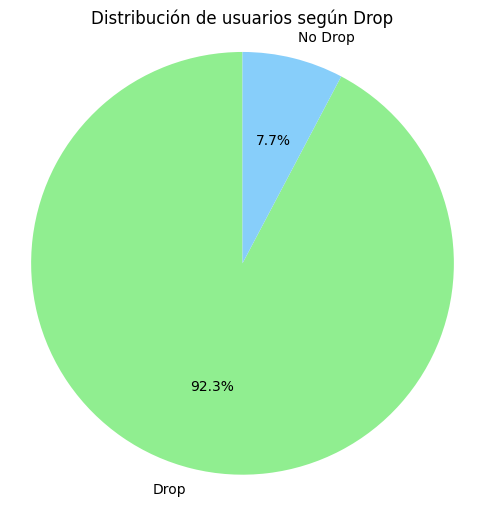

In [ ]:
labels = ['Drop', 'No Drop']
sizes = [11991, 12996 - 11991]

plt.figure(figsize=(6, 6))
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors=['lightgreen', 'lightskyblue'],
        startangle=90)
plt.title('Distribución de usuarios según Drop')
plt.axis('equal')
plt.show()

**Comentarios sobre métrica Drop**

- 12.996 usuarios fueron parte del onboarding (grupo observado).

- 11.991 usuarios (≈ 92.3%) hicieron drop, es decir:

 - No volvieron a usar la app después de ver la home page, o

 - Usaron la app sólo el mismo día de registro y luego no volvieron.

Por ende: el 92.27% de los usuarios nuevos no regresan a la aplicación luego del primer uso. Este es un valor muy elevado, lo que indica una fuerte necesidad de mejorar la experiencia inicial (onboarding). Justifica plenamente la necesidad del A/B testing implementado.

### **Métrica 2: Activación**
Mide el porcentaje de usuarios en onboarding que realizan una primera acción transaccional.

In [ ]:
# Paso 1: Crear una tabla que identifique usuarios activados
# Esto se logra haciendo un JOIN entre la tabla Onboarding y Transactions, y filtrando transacciones dentro de los 30 días desde first_login_dt.
spark.sql(
    """
    CREATE OR REPLACE TEMP VIEW activacion_analysis AS
    SELECT
        o.user_id,
        o.first_login_dt,
        MIN(t.transaction_dt) AS primera_transaccion_dt,
        CASE
            WHEN MIN(t.transaction_dt) IS NOT NULL THEN 1
            ELSE 0
        END AS activado_flag
    FROM Onboarding o
    LEFT JOIN Transactions t
        ON o.user_id = t.user_id
        AND t.transaction_dt BETWEEN o.first_login_dt AND DATE_ADD(o.first_login_dt, 30)
    GROUP BY o.user_id, o.first_login_dt
    """
)

DataFrame[]

In [ ]:
# Paso 2: Calcular el porcentaje de usuarios activados
spark.sql(
    """
    SELECT
        COUNT(*) AS total_usuarios,
        SUM(activado_flag) AS usuarios_activados,
        ROUND(SUM(activado_flag) * 100.0 / COUNT(*), 2) AS porcentaje_activacion
    FROM activacion_analysis
    """
).show()

+--------------+------------------+---------------------+
|total_usuarios|usuarios_activados|porcentaje_activacion|
+--------------+------------------+---------------------+
|         12996|               100|                 0.77|
+--------------+------------------+---------------------+



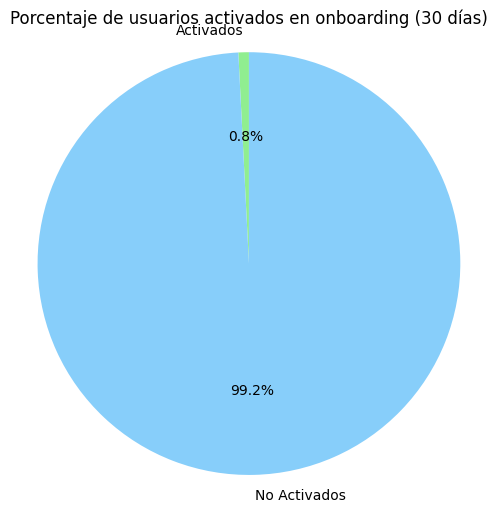

In [ ]:
labels = ['Activados', 'No Activados']
sizes = [104, 12996 - 104]  # 104 usuarios activados sobre 12.996

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightskyblue']
)
plt.title('Porcentaje de usuarios activados en onboarding (30 días)')
plt.axis('equal')
plt.show()

**Comentarios sobre métrica Activación**

Menos del 1% de los usuarios en onboarding (0.80%) realizaron al menos una transacción dentro de los primeros 30 días.
Esto sugiere un bajo nivel de interacción transaccional inicial, lo que puede deberse a:

*Problemas de adopción del producto:*

- Muchos usuarios se registran, pero no usan activamente los servicios.

- Puede estar fallando el diseño de la experiencia inicial.

*Onboarding poco efectivo:*

- Si el onboarding está pensado para guiar a los usuarios a crear productos financieros, el resultado sugiere que no está logrando ese objetivo.

- El flujo puede resultar confuso, largo, o no ofrece incentivos.

### **Métrica 3: Hábito**
Mide el porcentaje de usuarios en onboarding que realizan al menos 5 transacciones. Aquí, es importante entender que existen dos segmentos de usuarios: individuals y Sellers: los individuals son usuarios que realizan sólo transacciones de pago, mientras que los sellers también realizan transacciones de cobro. El hábito para cada segmento se mide de la siguiente forma:

1- *Individuals:* un usuario llega al **hábito** si realiza **5 transacciones en 5 días diferentes**, 	durante el período de onboarding (fijado en 30 días).

2- *Sellers:* un usuario llega al **hábito** si realiza **5 transacciones de cobro (sin importar los 	días)**, durante el período de onbarding (fijado en 30 días).


En la tabla Transactions, la columna segment indica si el usuario es "individual" (valor 1) o "seller" (valor 2).

En la tabla Transactions, la columna type indica el tipo de transacción ("pago" o "cobro").

Todas las transacciones y usuarios ya están filtrados por país (Brasil).

El período de onboarding es válido para los datos que estamos analizando.


In [ ]:
# Creamos una vista temporal con los usuarios que pasaron por la etapa de onboarding
spark.sql("""
CREATE OR REPLACE TEMP VIEW onboarding_users AS
SELECT DISTINCT user_id, first_login_dt
FROM Onboarding
""")

DataFrame[]

In [ ]:
# Creamos una vista con transacciones dentro del período de onboarding (30 días desde el primer login)
spark.sql("""
CREATE OR REPLACE TEMP VIEW transacciones_onboarding AS
SELECT t.user_id, t.transaction_dt, t.type, t.segment
FROM Transactions t
JOIN onboarding_users o ON t.user_id = o.user_id
WHERE DATEDIFF(t.transaction_dt, o.first_login_dt) BETWEEN 0 AND 30
""")

DataFrame[]

In [ ]:
# Un individual forma hábito si tiene transacciones en 5 días diferentes dentro del onboarding
spark.sql("""
CREATE OR REPLACE TEMP VIEW individual_habito AS
SELECT user_id
FROM transacciones_onboarding
WHERE segment = 1
GROUP BY user_id
HAVING COUNT(DISTINCT transaction_dt) >= 5
""")

DataFrame[]

In [ ]:
# Un seller forma hábito si hace 5 transacciones de tipo 'cobro' dentro del onboarding
spark.sql("""
CREATE OR REPLACE TEMP VIEW seller_habito AS
SELECT user_id
FROM transacciones_onboarding
WHERE segment = 2 AND type = 'cobro'
GROUP BY user_id
HAVING COUNT(*) >= 5
""")

DataFrame[]

In [ ]:
# Unificamos los usuarios con hábito: individuales y sellers
spark.sql("""
CREATE OR REPLACE TEMP VIEW habito_total AS
SELECT user_id FROM individual_habito
UNION
SELECT user_id FROM seller_habito
""")

DataFrame[]

In [ ]:
# Calculamos la métrica final: porcentaje de usuarios con hábito
spark.sql("""
SELECT
  COUNT(DISTINCT o.user_id) AS total_usuarios_onboarding,
  COUNT(DISTINCT h.user_id) AS usuarios_con_habito,
  ROUND(COUNT(DISTINCT h.user_id) * 100.0 / COUNT(DISTINCT o.user_id), 2) AS porcentaje_habito
FROM onboarding_users o
LEFT JOIN habito_total h ON o.user_id = h.user_id
""").show()

+-------------------------+-------------------+-----------------+
|total_usuarios_onboarding|usuarios_con_habito|porcentaje_habito|
+-------------------------+-------------------+-----------------+
|                    12996|                  0|             0.00|
+-------------------------+-------------------+-----------------+



**Otra estrategia para calcular Hábito**

Dado que, al usar *joins*, la métrica arrojó 0, a continuación se utiliza directamente la columna hábito de la tabla onboarding, que ya trae el valor booleano (1 si consolidó hábito, 0 si no), presumiblemente precalculado según la lógica de negocio de la consigna.

In [ ]:
# Porcentaje de usuarios en onboarding que tienen habito = 1
spark.sql("""
SELECT
  COUNT(*) AS total_usuarios,
  SUM(CASE WHEN habito = 1 THEN 1 ELSE 0 END) AS usuarios_con_habito,
  ROUND(SUM(CASE WHEN habito = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS porcentaje_habito
FROM Onboarding
""").show()

+--------------+-------------------+-----------------+
|total_usuarios|usuarios_con_habito|porcentaje_habito|
+--------------+-------------------+-----------------+
|         12996|               1531|            11.78|
+--------------+-------------------+-----------------+



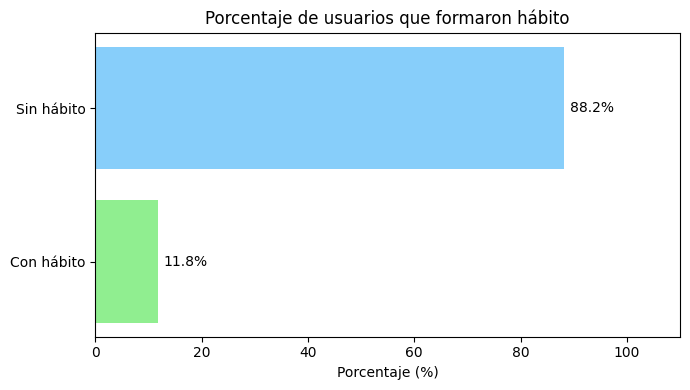

In [ ]:
valores = [11.8, 100 - 11.78]
etiquetas = ['Con hábito', 'Sin hábito']

plt.figure(figsize=(7, 4))
bars = plt.barh(etiquetas, valores, color=['lightgreen', 'lightskyblue'])

# Se agrega texto con los porcentajes sobre las barras
for bar, valor in zip(bars, valores):
    plt.text(valor + 1, bar.get_y() + bar.get_height() / 2,
             f'{valor:.1f}%', va='center')

plt.xlabel('Porcentaje (%)')
plt.title('Porcentaje de usuarios que formaron hábito')
plt.xlim(0, 110)  # un poco más de 100 para que entre el texto
plt.tight_layout()
plt.show()

**Comentarios sobre métrica Hábito**

- De los 12.996 usuarios en proceso de onboarding, 1.531 usuarios (11.8%) formaron hábito (es decir, usaron activamente la aplicación más allá del registro inicial).

- Esto indica que, si bien hay una gran pérdida de usuarios iniciales (como evidenció la métrica drop), existe un grupo minoritario pero significativo que se logra consolidar como usuarios activos.

- La formación de hábito es uno de los objetivos centrales del onboarding, por lo tanto, una tasa inferior al 12% sugiere oportunidades de mejora importantes:

 -  Revisar incentivos transaccionales tempranos.

 - Acompañamiento del usuario durante los primeros días.

 - Mejora de la interfaz para facilitar acciones frecuentes.

### **Métrica 4: Setup**
Mide el porcentaje de usuarios que realizaron al menos una acción de setup (por ejemplo, agregar una tarjeta de crédito a la billetera digital, activar la llave PIX, activar rendimientos en cuenta, etc.).

In [ ]:
# Se calcula el porcentaje de usuarios con setup
spark.sql(
    """
    SELECT
        COUNT(*) AS total_usuarios,
        SUM(CASE WHEN setup = true THEN 1 ELSE 0 END) AS usuarios_con_setup,
        ROUND(SUM(CASE WHEN setup = true THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS porcentaje_setup
    FROM Onboarding
    """
).show()

+--------------+------------------+----------------+
|total_usuarios|usuarios_con_setup|porcentaje_setup|
+--------------+------------------+----------------+
|         12996|              5520|           42.47|
+--------------+------------------+----------------+



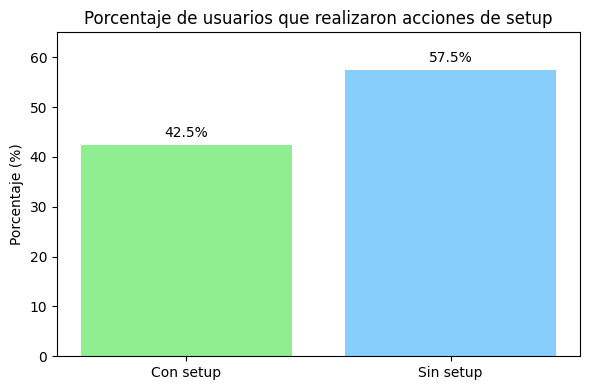

In [ ]:
etiquetas = ['Con setup', 'Sin setup']
valores = [42.47, 100 - 42.47]

plt.figure(figsize=(6, 4))
bars = plt.bar(etiquetas, valores, color=['lightgreen', 'lightskyblue'])

# Se agrega texto con porcentajes encima
for bar, valor in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width() / 2, valor + 1,
             f'{valor:.1f}%', ha='center', va='bottom')

plt.ylabel('Porcentaje (%)')
plt.title('Porcentaje de usuarios que realizaron acciones de setup')
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

**Comentarios sobre métrica Setup**

- 42,5% de los usuarios en onboarding realizaron al menos una acción de setup.

- Esto significa que menos de la mitad de los nuevos usuarios configuran funcionalidades clave como agregar tarjetas, activar PIX, rendimientos, etc., durante los primeros 30 días.